In [1]:
!pip install -q scikit-learn

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk, concatenate_datasets, Audio
import glob
from datasets import disable_caching
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
)

from torchvision.models import resnet18

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings

/content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings


## Load Data and DataLoader (dev and test set)

In [4]:
disable_caching()

# loading data

chunk_paths = sorted(glob.glob("speaker_chunks/chunk_*"))

chunks = []
for path in chunk_paths:
    ds = load_from_disk(path)
    ds = ds.cast_column("audio_path", Audio(sampling_rate=16000))
    chunks.append(ds)

full_dataset = concatenate_datasets(chunks)

In [5]:
split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]

temp = split["test"].train_test_split(test_size=0.5, seed=42)
dev_dataset = temp["train"]
test_dataset = temp["test"]

In [6]:
from dataset import Dataset_Builder

config = {"shortest_duration": 4.0}
dev_builder = Dataset_Builder(dev_dataset, **config)
dev_builder.filter()
dev_builder.preprocess()

test_builder = Dataset_Builder(test_dataset, **config)
test_builder.filter()
test_builder.preprocess()

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2402 [00:00<?, ? examples/s]

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2407 [00:00<?, ? examples/s]

In [7]:
dev_dataset = dev_builder.get_dataset()
test_dataset = test_builder.get_dataset()

In [12]:
def collate_fn(batch):
    log_mels = torch.stack([b["log_mel"] for b in batch])
    labels = torch.tensor([b["label"] for b in batch])
    return (log_mels, labels)

In [13]:
dev_loader = DataLoader(
    dev_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

## Build Model and Load checkpoint

In [14]:
NUM_CLASSES = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_path = "speaker_chunks/best_speaker_resnet.pth"

model = resnet18(weights=None)
model.fc = torch.nn.Linear(in_features=512, out_features=NUM_CLASSES, bias=True)

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Accuracy Evaluation (for dev set)

In [16]:
all_labels = []
all_probs = []
all_preds = []

correct  = 0
total = 0

model.to(DEVICE) # Ensure model is on the correct device

with torch.no_grad():
  for indx, (log_mels, labels) in tqdm(enumerate(dev_loader), total=len(dev_loader)):
      log_mels = log_mels.to(DEVICE)
      labels = labels.to(DEVICE)
      logits = model(log_mels)
      probs = torch.softmax(logits, dim=1)
      preds = torch.argmax(probs, dim=1)

      correct += torch.sum(preds == labels).item()
      total += len(labels)

      all_labels.extend(labels.cpu().numpy())
      all_probs.append(probs.cpu().numpy())
      all_preds.extend(preds.cpu().numpy())

accuracy = correct / total
print(f"Accuracy = {accuracy:4f}")

100%|██████████| 76/76 [04:18<00:00,  3.40s/it]

Accuracy = 0.951707


## Confusion matrix

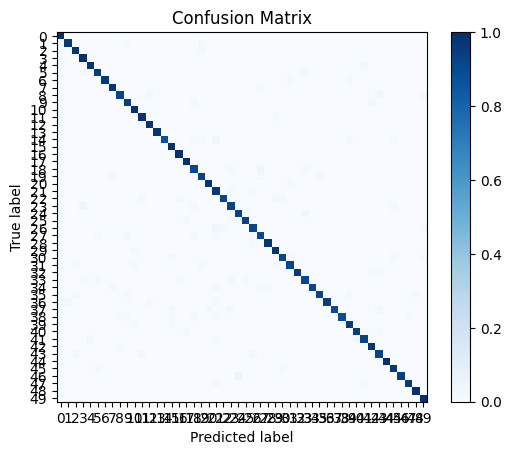

In [18]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", include_values=False, colorbar=True)
plt.title("Confusion Matrix")
plt.show()

In [19]:
import pandas as pd

report = classification_report(
    all_labels,
    all_preds,
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report).T

report_df = report_df.iloc[:-3]

report_df

,precision,recall,f1-score,support
0,0.955556,1.000000,0.977273,43.0
1,0.981481,0.963636,0.972477,55.0
2,0.952381,0.983607,0.967742,61.0
3,0.918367,1.000000,0.957447,45.0
4,0.977273,0.977273,0.977273,44.0
5,0.926829,0.950000,0.938272,40.0
6,1.000000,0.957447,0.978261,47.0
7,0.962264,0.980769,0.971429,52.0
8,0.945946,0.921053,0.933333,38.0
9,0.918033,0.949153,0.933333,59.0


In [20]:
from sklearn.metrics import precision_recall_fscore_support

p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="micro"
)

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro"
)

print(f"Micro Precision : {p_micro:.4f}")
print(f"Micro Recall    : {r_micro:.4f}")
print(f"Micro F1-score  : {f_micro:.4f}")

print(f"Macro Precision : {p_macro:.4f}")
print(f"Macro Recall    : {r_macro:.4f}")
print(f"Macro F1-score  : {f_macro:.4f}")

Micro Precision : 0.9517
Micro Recall    : 0.9517
Micro F1-score  : 0.9517
Macro Precision : 0.9526
Macro Recall    : 0.9518
Macro F1-score  : 0.9516


## ROC Evaluation

In [21]:
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)

y_true = label_binarize(all_labels, classes=np.arange(NUM_CLASSES))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

roc_auc["macro"] = roc_auc_score(y_true, all_probs, average="macro", multi_class="ovr")

print(f"Micro-average ROC AUC: {roc_auc['micro']:.3f}")
print(f"Macro-average ROC AUC: {roc_auc['macro']:.3f}")


Micro-average ROC AUC: 0.999
Macro-average ROC AUC: 0.999


## Plot out ROC Curve

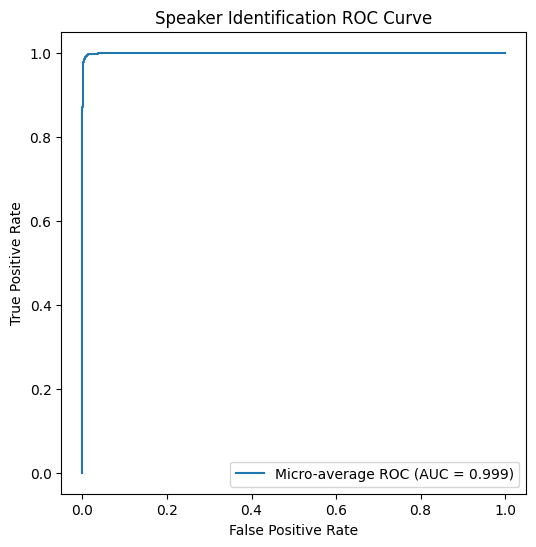

In [22]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Speaker Identification ROC Curve")
plt.legend()

plt.show()

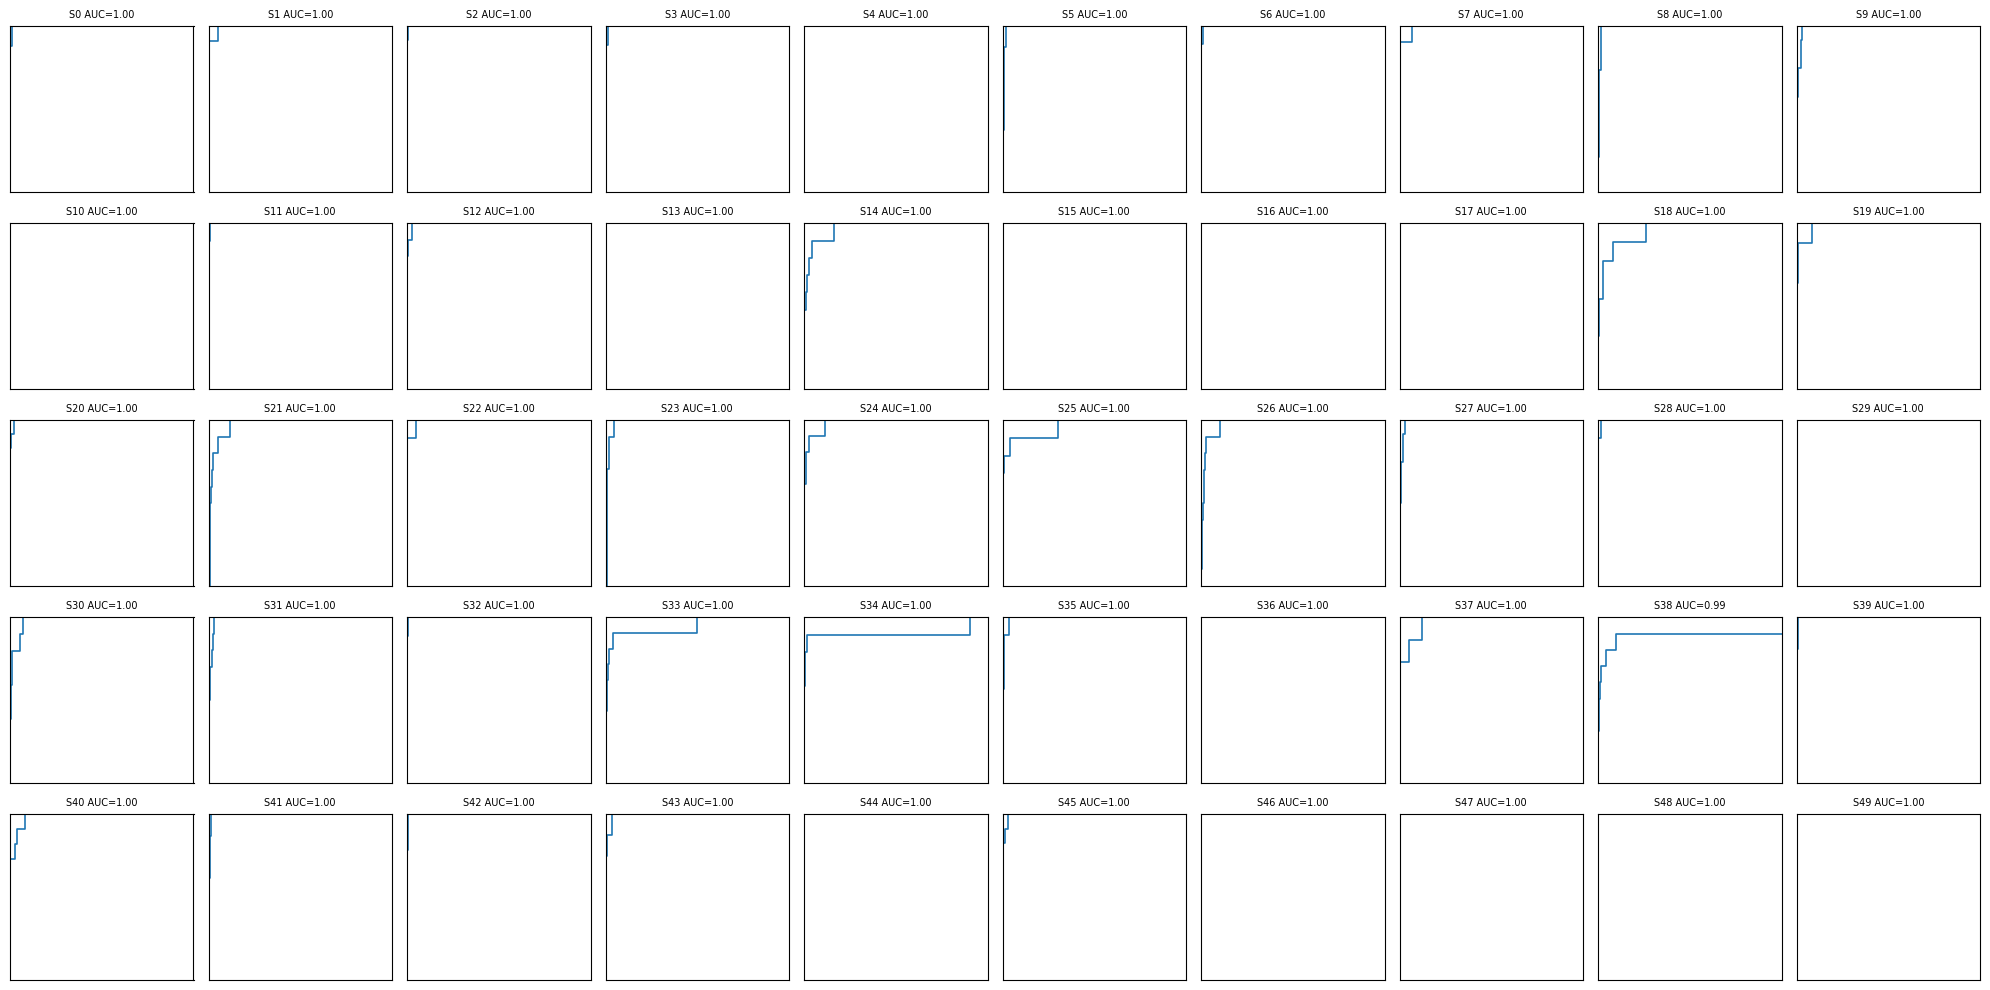

In [24]:
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
axes = axes.ravel()

for i in range(NUM_CLASSES):
    ax = axes[i]

    ax.plot(fpr[i], tpr[i], linewidth=1.2)

    ax.set_title(f"S{i} AUC={roc_auc[i]:.2f}", fontsize=7)

    ax.set_xlim(0, 0.2)
    ax.set_ylim(0.8, 1.0)

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()